In [1]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [8]:
data = pd.read_csv("../Datasets/Ice_sell.csv")
df = pd.DataFrame(data)
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [9]:
x = df[["Temperature (°C)"]]
y = df["Ice Cream Sales (units)"]

In [11]:
degree=2
poly = PolynomialFeatures(degree=degree)
x_poly = poly.fit_transform(x)
print("Polynomial Features")
print(x_poly)

Polynomial Features
[[ 1.00000000e+00 -4.66226268e+00  2.17366933e+01]
 [ 1.00000000e+00 -4.31655945e+00  1.86326855e+01]
 [ 1.00000000e+00 -4.21398476e+00  1.77576676e+01]
 [ 1.00000000e+00 -3.94966109e+00  1.55998227e+01]
 [ 1.00000000e+00 -3.57855372e+00  1.28060467e+01]
 [ 1.00000000e+00 -3.45571170e+00  1.19419433e+01]
 [ 1.00000000e+00 -3.10844012e+00  9.66239999e+00]
 [ 1.00000000e+00 -3.08130332e+00  9.49443018e+00]
 [ 1.00000000e+00 -2.67246083e+00  7.14204687e+00]
 [ 1.00000000e+00 -2.65228679e+00  7.03462523e+00]
 [ 1.00000000e+00 -2.65149803e+00  7.03044182e+00]
 [ 1.00000000e+00 -2.28826400e+00  5.23615213e+00]
 [ 1.00000000e+00 -2.11186969e+00  4.45999359e+00]
 [ 1.00000000e+00 -1.81893761e+00  3.30853403e+00]
 [ 1.00000000e+00 -1.66034773e+00  2.75675458e+00]
 [ 1.00000000e+00 -1.32637898e+00  1.75928121e+00]
 [ 1.00000000e+00 -1.17312327e+00  1.37621820e+00]
 [ 1.00000000e+00 -7.73330043e-01  5.98039356e-01]
 [ 1.00000000e+00 -6.73752802e-01  4.53942838e-01]
 [ 1.000000

In [12]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
num_features = x.select_dtypes(include=["int64","float64"]).columns
cat_features = x.select_dtypes(include=["object"]).columns

In [15]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [16]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

model.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred = model.predict(X_test)
print("Prediction: ",y_pred)

Prediction:  [10.24499852 25.82807714 31.8241041  24.61704203  4.43380256  4.00785672
  3.58277491  3.17865087  7.86990452  2.91591368]


In [18]:
print("Model Performance: ")
print("r2 score: ",r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Model Performance: 
r2 score:  0.8430551371938841
MAE: 3.229981983659728
MSE: 14.878796440981475
RMSE: 3.8573042971719866


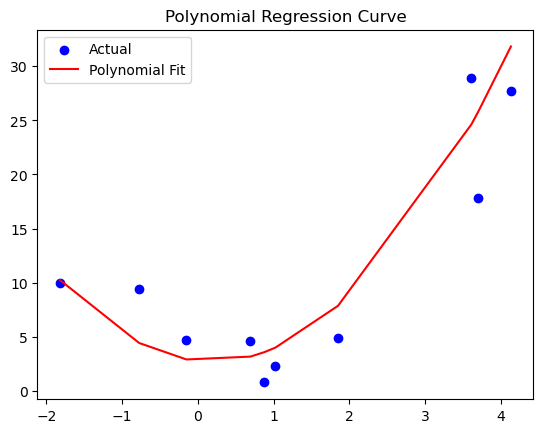

In [20]:
if x.shape[1] == 1:
    plt.scatter(X_test, y_test, color='blue', label="Actual")
    
    # Sort for smooth curve
    sorted_idx = X_test.iloc[:, 0].argsort()
    X_sorted = X_test.iloc[sorted_idx]
    y_sorted_pred = model.predict(X_sorted)
    
    plt.plot(X_sorted, y_sorted_pred, color='red', label="Polynomial Fit")
    plt.legend()
    plt.title("Polynomial Regression Curve")
    plt.show()
else:
    print("\n⚠️ Multiple features detected → Use pairplot/heatmap instead")



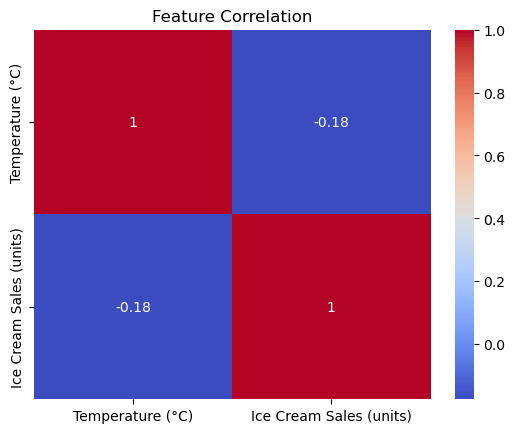

In [22]:
#Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()